In [ ]:
# Настройка Jupyter
%matplotlib inline


In [ ]:
import os

# Сохранение путей к файлам датасета
DATA_PATH = r"D:\Projects\Jupyter_Notebook_Projects\Project_2268\ieee-fraud-detection"

trans_file = os.path.join(DATA_PATH, 'train_transaction.csv')
id_file = os.path.join(DATA_PATH, 'train_identity.csv')

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
transactions = pd.read_csv(trans_file)
identity = pd.read_csv(id_file)

# Merge datasets
data = transactions.merge(identity, on="TransactionID", how="left")

# Remove columns with too many missing values
missing_ratio = data.isnull().mean()
data = data.loc[:, missing_ratio < 0.8]

# Remove constant columns
constant_cols = data.columns[data.nunique(dropna=False) <= 1]
data = data.drop(columns=constant_cols)

# Separate target and features
y = data["isFraud"]
X = data.drop(["isFraud", "TransactionID"], axis=1)

# Identify column types
num_cols = X.select_dtypes(exclude=["object"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Fill missing values
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Unknown")

# Encode categorical variables
le = LabelEncoder()

for c in cat_cols:
    X[c] = le.fit_transform(X[c].astype(str))


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Сохранение ОЧИЩЕННЫХ данных
np.savez('artifacts/preprocessed_data.npz',
         X_train=X_train.astype(np.float32),
         y_train=y_train.astype(np.int64),
         X_test=X_test.astype(np.float32),
         y_test=y_test.astype(np.int64))
print("Данные сохранены")

Данные сохранены


In [ ]:
# Подготовка DataLoader'ов
print("Подготовка к обучению MLP (с помощью PyTorch)")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, f1_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Проверка GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Конвертация DataFrame -> numpy -> tensor (float32)
X_train_t = torch.FloatTensor(X_train.values).to(device)
y_train_t = torch.FloatTensor(y_train.values).unsqueeze(1).to(device)
X_test_t = torch.FloatTensor(X_test.values).to(device)
y_test_t = torch.FloatTensor(y_test.values).unsqueeze(1).to(device)

# DataLoader для батчей (критично для стабильности градиентов!)
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 2048  # оптимально для fraud detection
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")
print(f"Размер входа: {X_train_t.shape[1]} фич")

Подготовка к обучению MLP (с помощью PyTorch)
Используется устройство: cpu
Train batches: 231, Test batches: 58
Размер входа: 358 фич


In [ ]:
# Создание модели MLP
class FraudMLP(nn.Module):
    def __init__(self, input_size, dropout_rate=0.3):
        super(FraudMLP, self).__init__()

        # Входной слой + 4 скрытых + выход
        self.layers = nn.Sequential(
            # Layer 1: 512 нейронов
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2: 256 нейронов
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 3: 128 нейронов
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 4: 64 нейрона
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Выходной слой (сигмоида для вероятностей)
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

# Инициализация модели
input_size = X_train.shape[1]
model = FraudMLP(input_size).to(device)
print(f"Модель создана: {sum(p.numel() for p in model.parameters()):,} параметров")

Модель создана: 358,273 параметров


In [ ]:
# Настройка обучения
criterion = nn.BCELoss()  # Binary Cross Entropy для вероятностей
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print("Loss: BCE, Optimizer: AdamW, LR: 0.001")

Loss: BCE, Optimizer: AdamW, LR: 0.001


In [ ]:
# Процесс обучения модели
print("\nНАЧИНАЕМ ОБУЧЕНИЕ...")
best_auc = 0
train_losses, val_aucs = [], []

for epoch in range(15):
    # === TRAIN ===
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()

        # Градиентный clipping (против взрыва градиентов)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # === VALIDATION ===
    model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            outputs = model(batch_x)
            val_preds.append(outputs.cpu().numpy())
            val_true.append(batch_y.cpu().numpy())

    val_preds = np.concatenate(val_preds)[:, 0]
    val_true = np.concatenate(val_true)[:, 0]
    val_auc = roc_auc_score(val_true, val_preds)
    val_aucs.append(val_auc)

    scheduler.step(val_auc)  # Learning Rate (LR) снижается если AUC не растет

    print(f"Epoch {epoch+1:2d}: Loss={avg_train_loss:.4f}, AUC={val_auc:.4f}, LR={optimizer.param_groups[0]['lr']:.4f}")

    # Сохранение лучшей модели
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), 'artifacts/mlp_best_model.pth')
        print(f"    Новая лучшая модель с AUC={val_auc:.4f}")

print(f"\nОбучение завершено. Лучшее значение AUC: {best_auc:.4f}")



НАЧИНАЕМ ОБУЧЕНИЕ...
Epoch  1: Loss=0.2181, AUC=0.6142, LR=0.0010
    Новая лучшая модель с AUC=0.6142
Epoch  2: Loss=0.1495, AUC=0.6289, LR=0.0010
    Новая лучшая модель с AUC=0.6289
Epoch  3: Loss=0.1458, AUC=0.7350, LR=0.0010
    Новая лучшая модель с AUC=0.7350
Epoch  4: Loss=0.1445, AUC=0.7131, LR=0.0010
Epoch  5: Loss=0.1429, AUC=0.6862, LR=0.0005
Epoch  6: Loss=0.1408, AUC=0.7397, LR=0.0005
    Новая лучшая модель с AUC=0.7397
Epoch  7: Loss=0.1400, AUC=0.7568, LR=0.0005
    Новая лучшая модель с AUC=0.7568
Epoch  8: Loss=0.1393, AUC=0.7507, LR=0.0005
Epoch  9: Loss=0.1384, AUC=0.7362, LR=0.0003
Epoch 10: Loss=0.1371, AUC=0.7855, LR=0.0003
    Новая лучшая модель с AUC=0.7855
Epoch 11: Loss=0.1365, AUC=0.7608, LR=0.0003
Epoch 12: Loss=0.1359, AUC=0.7894, LR=0.0003
    Новая лучшая модель с AUC=0.7894
Epoch 13: Loss=0.1353, AUC=0.7841, LR=0.0001
Epoch 14: Loss=0.1348, AUC=0.7959, LR=0.0001
    Новая лучшая модель с AUC=0.7959
Epoch 15: Loss=0.1340, AUC=0.7901, LR=0.0001

Обучен

In [ ]:
# Финальная оценка
model.load_state_dict(torch.load('artifacts/mlp_best_model.pth'))
model.eval()

with torch.no_grad():
    y_pred_proba_mlp = model(X_test_t).cpu().numpy()[:, 0]
    y_pred_mlp = (y_pred_proba_mlp > 0.5).astype(int)

# Ключевые метрики для fraud detection
roc_auc = roc_auc_score(y_test, y_pred_proba_mlp)
f1 = f1_score(y_test, y_pred_mlp)
pr = average_precision_score(y_test, y_pred_proba_mlp)

print("RF ROC-AUC:", roc_auc)
print("RF F1-score:", f1)
print("RF PR-AUC:", pr)

RF ROC-AUC: 0.7959421753563927
RF F1-score: 0.0
RF PR-AUC: 0.19410450490179243


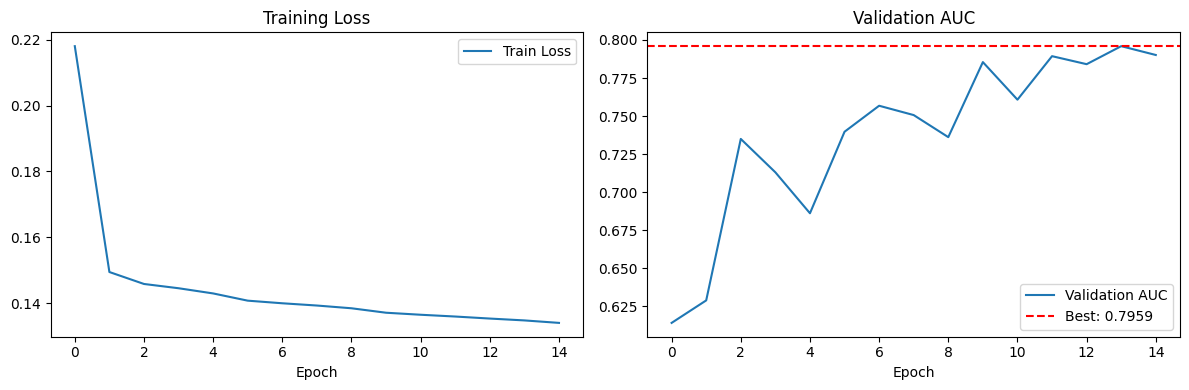

In [ ]:
# Визуализация и сохранение
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_aucs, label='Validation AUC')
plt.axhline(y=best_auc, color='r', linestyle='--', label=f'Best: {best_auc:.4f}')
plt.title('Validation AUC')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('artifacts/mlp_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()